# Notebook 02 — Métricas iniciales (PSNR / SSIM)

Objetivo: medir PSNR y SSIM entre la imagen original y la colorizada comparando en **escala de grises** (ó canal **L**).  
Salida: `../eval/tables/metrics.csv` y mosaico en `../eval/figs/`.

In [6]:
from pathlib import Path
import numpy as np
import cv2 as cv
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

BASE = Path('..').resolve()
DATA_RAW = BASE / 'data' / 'raw'
DATA_RES = BASE / 'data' / 'results'
EVAL_T  = BASE / 'eval' / 'tables'
EVAL_F  = BASE / 'eval' / 'figs'
EVAL_T.mkdir(parents=True, exist_ok=True)
EVAL_F.mkdir(parents=True, exist_ok=True)

print('RAW =', DATA_RAW)
print('RES =', DATA_RES)

RAW = C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\data\raw
RES = C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\data\results


## Utilidades de carga y emparejado
Convertimos a **gris** para calcular PSNR/SSIM y emparejamos por nombre.

In [7]:
def imread_gray(path):
    bgr = cv.imread(str(path))
    if bgr is None:
        return None
    return cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

def list_pairs():
    # Empareja raw/<name>.* con results/<name>_color.* o <name>.*
    pairs = []
    raw_files = [p for p in DATA_RAW.glob('*') if p.is_file()]
    for rf in raw_files:
        name = rf.stem
        candidates = list(DATA_RES.glob(f'{name}_color.*')) + list(DATA_RES.glob(f'{name}.*'))
        if candidates:
            pairs.append((rf, candidates[0]))
    return pairs

## Cálculo de métricas y exportación a CSV

In [8]:
rows = []
pairs = list_pairs()
for raw_p, res_p in pairs:
    gt  = imread_gray(raw_p)
    out = imread_gray(res_p)
    if gt is None or out is None:
        continue
    if gt.shape != out.shape:
        out = cv.resize(out, (gt.shape[1], gt.shape[0]))
    psnr_val = psnr(gt, out, data_range=255)
    ssim_val = ssim(gt, out, data_range=255)
    rows.append({'name': raw_p.stem, 'psnr': psnr_val, 'ssim': ssim_val})

df = pd.DataFrame(rows).sort_values('name')
csv_path = EVAL_T / 'metrics.csv'
df.to_csv(csv_path, index=False)
df

,name,psnr,ssim
0,ejemplo,44.874539,0.998338


## Mosaico antes/después (primeras N imágenes)

CSV  -> C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\eval\tables\metrics.csv
FIG  -> C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\eval\figs\mosaic_metrics.png


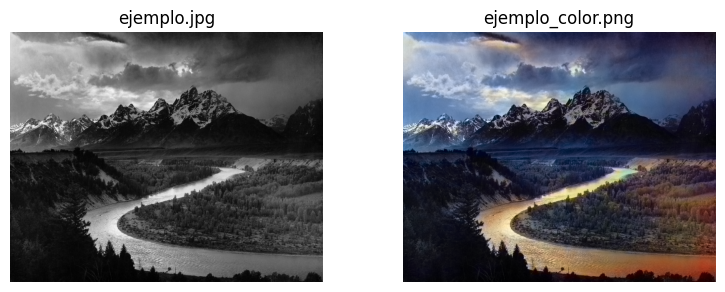

In [9]:
N = min(3, len(pairs))
fig, axes = plt.subplots(N, 2, figsize=(8, 3*N))
if N == 1:
    axes = np.array([axes])
for i in range(N):
    raw_p, res_p = pairs[i]
    raw_bgr = cv.imread(str(raw_p))
    res_bgr = cv.imread(str(res_p))
    axes[i,0].imshow(cv.cvtColor(raw_bgr, cv.COLOR_BGR2RGB)); axes[i,0].set_title(raw_p.name); axes[i,0].axis('off')
    axes[i,1].imshow(cv.cvtColor(res_bgr, cv.COLOR_BGR2RGB)); axes[i,1].set_title(res_p.name); axes[i,1].axis('off')
plt.tight_layout()
fig_path = EVAL_F / 'mosaic_metrics.png'
plt.savefig(fig_path, dpi=150)
print('CSV  ->', csv_path)
print('FIG  ->', fig_path)